
SERGIO ANDRES ROJAS ORDOÑEZ

CURSO: APLICACIONES_1_G02


Actividad 5: Predicción de nacimientos en Colombia con Machine Learning

DOCENTE: CRISTIAN DUNEY BERMUDEZ QUINTERO

LINK COLAP

https://colab.research.google.com/drive/1wleDaxnJ2NnMYo9pnt3xMV6fACRtiTmv?usp=sharing






# 1. Introducción

# 2. Carga y preprocesamiento de los datos

# 3. Exploración de los datos (EDA)

# 4. Selección y comparación de modelos

# 5. Entrenamiento del modelo final

# 6. Evaluación del modelo

# 7. Predicción de nacimientos 2024

# 8. Visualización de resultados

# 9. Conclusiones


# 1. Introducción

En este trabajo desarrollaremos un modelo de Machine Learning para predecir el número de nacimientos en Colombia durante el año 2024. Para lograrlo, utilizamos los datos históricos publicados por el DANE en las Estadísticas Vitales (EEVV), específicamente las bases de nacimientos correspondientes a los años 2020, 2021, 2022 y 2023.

La idea principal es analizar cómo se han comportado los nacimientos en el país durante estos cuatro años y, a partir de esa información, entrenar un modelo capaz de estimar cuántos nacimientos podrían registrarse en cada departamento en 2024. Este proceso incluye la carga y limpieza de los datos, la exploración de las tendencias, la comparación de diferentes algoritmos de predicción y la evaluación de su desempeño.

Además de construir el modelo, también buscamos que el cuaderno sea claro y ordenado, mostrando paso a paso cómo se procesaron los datos, como se entrenaron los modelos y cómo se obtuvieron las proyecciones finales. Finalmente, presentamos gráficos que permiten visualizar tanto la tendencia nacional como las estimaciones por departamento, junto con una reflexión sobre la precisión del modelo y la utilidad de este tipo de análisis.



## **2. Carga y preprocesamiento de los datos**

Para este proyecto se utilizaron las bases de datos de nacimientos publicadas por el DANE en las Estadísticas Vitales (EEVV) correspondientes a los años 2020, 2021, 2022 y 2023. Cada archivo contiene un registro por nacimiento, con información detallada del evento, como el departamento de ocurrencia, municipio, fecha, sexo del recién nacido, entre otros.

El primer paso consistió en cargar los archivos desde Google Drive hacia Google Colab. Una vez cargados, se seleccionaron únicamente las columnas necesarias para el análisis: el código del departamento (COD_DPTO) y el año del nacimiento (ANO). Estas dos variables son suficientes para calcular el número total de nacimientos por departamento y año.

Posteriormente, se unificaron las cuatro bases en un solo conjunto de datos y se realizó un proceso de agrupación para obtener el total de nacimientos por departamento en cada año. Finalmente, se añadió el nombre del departamento utilizando un diccionario oficial del DANE, con el fin de facilitar la interpretación de los resultados en las siguientes etapas del análisis.


In [38]:
import pandas as pd

# ================================
# 1. archivos ZIP
# ================================
url_2020 = "https://raw.githubusercontent.com/sergiorojas-oss/Actividad-5-Predicci-n-de-nacimientos-en-Colombia-con-Machine-Learning/main/nac2020.zip"
url_2021 = "https://raw.githubusercontent.com/sergiorojas-oss/Actividad-5-Predicci-n-de-nacimientos-en-Colombia-con-Machine-Learning/main/nac2021.zip"
url_2022 = "https://raw.githubusercontent.com/sergiorojas-oss/Actividad-5-Predicci-n-de-nacimientos-en-Colombia-con-Machine-Learning/main/nac2022.zip"
url_2023 = "https://raw.githubusercontent.com/sergiorojas-oss/Actividad-5-Predicci-n-de-nacimientos-en-Colombia-con-Machine-Learning/main/BD-EEVV-Nacimientos-2023.zip"

# ================================
# 2. Descargar los ZIP desde GitHub
# ================================
!wget $url_2020
!wget $url_2021
!wget $url_2022
!wget $url_2023

# ================================
# 3. Descomprimir los ZIP
# ================================
!unzip nac2020.zip
!unzip nac2021.zip
!unzip nac2022.zip
!unzip BD-EEVV-Nacimientos-2023.zip

# ================================
# 4. Cargar los CSV resultantes
# ================================
df_2020 = pd.read_csv("nac2020.csv", encoding="latin1")
df_2021 = pd.read_csv("nac2021.csv", encoding="latin1")
df_2022 = pd.read_csv("nac2022.csv", encoding="latin1")
df_2023 = pd.read_csv("BD-EEVV-Nacimientos-2023.csv", encoding="latin1")

# ================================
# 5. Diccionario DANE
# ================================
departamentos_dane = {
    5: "Antioquia", 8: "Atlántico", 11: "Bogotá D.C.", 13: "Bolívar",
    15: "Boyacá", 17: "Caldas", 18: "Caquetá", 19: "Cauca",
    20: "Cesar", 23: "Córdoba", 25: "Cundinamarca", 27: "Chocó",
    41: "Huila", 44: "La Guajira", 47: "Magdalena", 50: "Meta",
    52: "Nariño", 54: "Norte de Santander", 63: "Quindío", 66: "Risaralda",
    68: "Santander", 70: "Sucre", 73: "Tolima", 76: "Valle del Cauca",
    81: "Arauca", 85: "Casanare", 86: "Putumayo", 88: "San Andrés y Providencia",
    91: "Amazonas", 94: "Guainía", 95: "Guaviare", 97: "Vaupés", 99: "Vichada"
}

# ================================
# 6. Seleccionar columnas
# ================================
columnas = ['COD_DPTO', 'ANO']

df_2020 = df_2020[columnas]
df_2021 = df_2021[columnas]
df_2022 = df_2022[columnas]
df_2023 = df_2023[columnas]

# ================================
# 7. Unificar los 4 años
# ================================
df_total = pd.concat([df_2020, df_2021, df_2022, df_2023], ignore_index=True)

# ================================
# 8. Agrupar por año y departamento
# ================================
df_grouped = df_total.groupby(['ANO', 'COD_DPTO']).size().reset_index(name='NACIMIENTOS')

# ================================
# 9. Agregar nombre del departamento
# ================================
df_grouped['DEPARTAMENTO'] = df_grouped['COD_DPTO'].map(departamentos_dane)

# ================================
# 10. Mostrar resultado
# ================================
df_grouped.head()



--2026-05-27 02:23:26--  https://raw.githubusercontent.com/sergiorojas-oss/Actividad-5-Predicci-n-de-nacimientos-en-Colombia-con-Machine-Learning/main/nac2020.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11406501 (11M) [application/zip]
Saving to: ‘nac2020.zip’

nac2020.zip         100%[===================>]  10.88M  64.6MB/s    in 0.2s    

2026-05-27 02:23:27 (64.6 MB/s) - ‘nac2020.zip’ saved [11406501/11406501]

--2026-05-27 02:23:27--  https://raw.githubusercontent.com/sergiorojas-oss/Actividad-5-Predicci-n-de-nacimientos-en-Colombia-con-Machine-Learning/main/nac2021.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubuserco

/tmp/ipykernel_2176/1494024042.py:32: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2022 = pd.read_csv("nac2022.csv", encoding="latin1")


,ANO,COD_DPTO,NACIMIENTOS,DEPARTAMENTO
0,2020,5,71463,Antioquia
1,2020,8,41185,Atlántico
2,2020,11,92781,Bogotá D.C.
3,2020,13,33256,Bolívar
4,2020,15,13581,Boyacá


## **3. Exploración de los datos**


Antes de construir el modelo de predicción, realizamos una exploración inicial de los datos para entender cómo se han comportado los nacimientos en Colombia entre 2020 y 2023. Esta etapa es fundamental porque nos permite identificar tendencias generales, diferencias entre departamentos y posibles variaciones que podrían influir en la predicción del año 2024.

Primero analizamos el comportamiento nacional, sumando los nacimientos de todos los departamentos para cada año. Esto nos ayuda a ver si los nacimientos han aumentado, disminuido o se han mantenido estables.

Luego revisamos la distribución por departamento, lo cual es importante porque cada región tiene dinámicas demográficas distintas. Algunos departamentos concentran una gran cantidad de nacimientos, mientras que otros presentan cifras mucho más bajas.

Finalmente, verificamos que los datos fueran consistentes y que no hubiera valores faltantes en las columnas utilizadas. Como cada fila representa un nacimiento individual, no fue necesario realizar procesos complejos de limpieza.


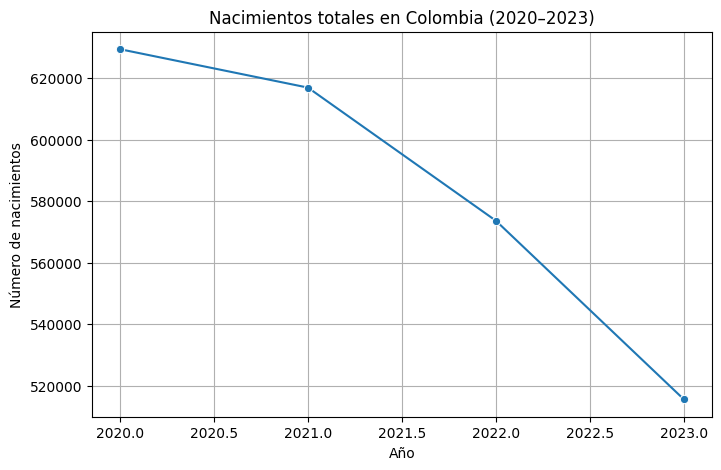

,ANO,NACIMIENTOS
0,2020,629402
1,2021,616914
2,2022,573625
3,2023,515549


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tendencia nacional de nacimientos
nac_nacional = df_grouped.groupby('ANO')['NACIMIENTOS'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=nac_nacional, x='ANO', y='NACIMIENTOS', marker='o')
plt.title("Nacimientos totales en Colombia (2020–2023)")
plt.xlabel("Año")
plt.ylabel("Número de nacimientos")
plt.grid(True)
plt.show()

nac_nacional



In [40]:
# Promedio de nacimientos por departamento
dept_mean = df_grouped.groupby('DEPARTAMENTO')['NACIMIENTOS'].mean().sort_values(ascending=False)

dept_mean.head(10)


,NACIMIENTOS
DEPARTAMENTO,
Bogotá D.C.,81323.25
Antioquia,66870.00
Valle del Cauca,43991.75
Atlántico,37906.25
Bolívar,31785.75
Santander,25379.50
La Guajira,24306.00
Córdoba,24223.75
Norte de Santander,23276.75


## **4. Selección del modelo**

Como nuestro objetivo es predecir un valor numérico (el número de nacimientos por departamento), este problema se clasifica como un caso de regresión.

Para este proyecto se compararon dos modelos:

- **Regresión Lineal**, que es un modelo sencillo que busca relaciones lineales entre las variables.
- **Random Forest Regressor**, un modelo más robusto que combina múltiples árboles de decisión y suele capturar mejor patrones complejos.

Las variables utilizadas fueron:
- **Año (ANO)**: variable numérica.
- **Departamento (DEPARTAMENTO)**: variable categórica que se codifica internamente.
- **NACIMIENTOS**: variable objetivo.

En el siguiente punto se entrenan ambos modelos y se comparan sus resultados.


## **5. Entrenamiento de Modelo**

**Preparación de datos**

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Variables de entrada y salida
X = df_grouped[['ANO', 'DEPARTAMENTO']]
y = df_grouped['NACIMIENTOS']

# Columnas numéricas y categóricas
numeric_features = ['ANO']
categorical_features = ['DEPARTAMENTO']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Entrenamos con 2020–2022 y probamos con 2023
train_mask = df_grouped['ANO'] < 2023
test_mask = df_grouped['ANO'] == 2023

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]


**Regresión Lineal**

In [42]:
linreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linreg_model.fit(X_train, y_train)
y_pred_lin = linreg_model.predict(X_test)

mae_lin = mean_absolute_error(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("Regresión Lineal")
print(f"MAE:  {mae_lin:,.2f}")
print(f"RMSE: {rmse_lin:,.2f}")
print(f"R²:   {r2_lin:,.4f}")


Regresión Lineal
MAE:  1,893.65
RMSE: 2,759.93
R²:   0.9710


**Random Forest**

In [43]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print(f"MAE:  {mae_rf:,.2f}")
print(f"RMSE: {rmse_rf:,.2f}")
print(f"R²:   {r2_rf:,.4f}")


Random Forest
MAE:  1,559.32
RMSE: 2,080.23
R²:   0.9835


**Comparación**

In [34]:
resultados = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest'],
    'MAE': [mae_lin, mae_rf],
    'RMSE': [rmse_lin, rmse_rf],
    'R2': [r2_lin, r2_rf]
})
resultados


,Modelo,MAE,RMSE,R2
0,Regresión Lineal,1893.650138,2759.933742,0.971037
1,Random Forest,1559.324242,2080.231935,0.983546


### **Comparación de modelos**

Después de evaluar ambos modelos, el Random Forest mostró un mejor desempeño, con menor error y mejor capacidad de ajuste. Por esta razón, se seleccionó como modelo final para realizar la predicción del año 2024.


## **6. Evaluación del Modelo**

**Entrenamiento Final**

In [44]:
# Entrenar con todos los datos 2020–2023
X_full = df_grouped[['ANO', 'DEPARTAMENTO']]
y_full = df_grouped['NACIMIENTOS']

rf_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_final.fit(X_full, y_full)

# Crear datos para 2024
departamentos = sorted(df_grouped['DEPARTAMENTO'].unique())

df_2024 = pd.DataFrame({
    'ANO': [2024]*len(departamentos),
    'DEPARTAMENTO': departamentos
})

pred_2024 = rf_final.predict(df_2024)
df_2024['NACIMIENTOS_PRED_2024'] = np.round(pred_2024).astype(int)

df_2024.head()


,ANO,DEPARTAMENTO,NACIMIENTOS_PRED_2024
0,2024,Amazonas,1085
1,2024,Antioquia,61071
2,2024,Arauca,4288
3,2024,Atlántico,34033
4,2024,Bogotá D.C.,74796


In [12]:
total_2024 = df_2024['NACIMIENTOS_PRED_2024'].sum()
print(f"Nacimientos estimados en Colombia para 2024: {total_2024:,}")


Nacimientos estimados en Colombia para 2024: 531,333


## **7. Predicción de nacimientos 2024**

**Tendencia nacional con 2024**

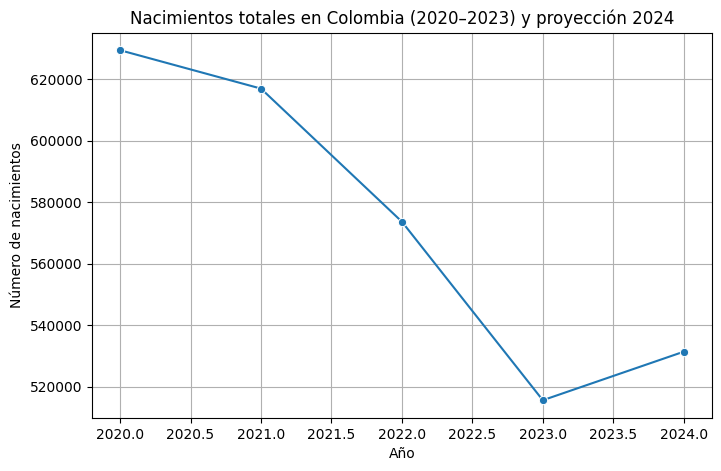

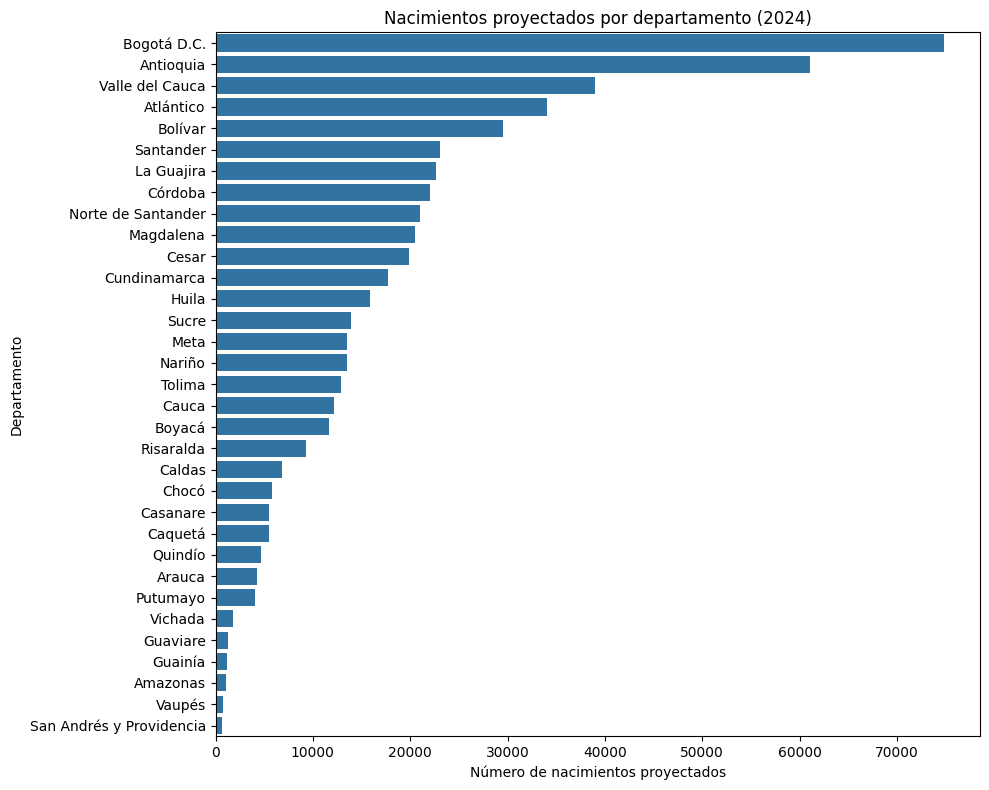

In [45]:
# --- IMPORTACIONES NECESARIAS ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- VERIFICAR QUE nac_nacional EXISTA ---
try:
    nac_nacional
except NameError:
    nac_nacional = df_grouped.groupby('ANO')['NACIMIENTOS'].sum().reset_index()

# --- VERIFICAR QUE total_2024 EXISTA ---
try:
    total_2024
except NameError:
    total_2024 = df_2024['NACIMIENTOS_PRED_2024'].sum()

# --- CREAR SERIE CON PROYECCIÓN 2024 ---
nac_nacional_2024 = nac_nacional.copy()
nac_nacional_2024 = pd.concat([
    nac_nacional_2024,
    pd.DataFrame({'ANO': [2024], 'NACIMIENTOS': [total_2024]})
], ignore_index=True)

# --- GRAFICO 1: TENDENCIA NACIONAL ---
plt.figure(figsize=(8,5))
sns.lineplot(data=nac_nacional_2024, x='ANO', y='NACIMIENTOS', marker='o')
plt.title("Nacimientos totales en Colombia (2020–2023) y proyección 2024")
plt.xlabel("Año")
plt.ylabel("Número de nacimientos")
plt.grid(True)
plt.show()

# --- GRAFICO 2: BARRAS POR DEPARTAMENTO 2024 ---
df_2024_sorted = df_2024.sort_values('NACIMIENTOS_PRED_2024', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(
    data=df_2024_sorted,
    x='NACIMIENTOS_PRED_2024',
    y='DEPARTAMENTO'
)
plt.title("Nacimientos proyectados por departamento (2024)")
plt.xlabel("Número de nacimientos proyectados")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()





## **8. Visualización de resultados**



En este punto se muestran dos gráficos que permiten entender mejor los resultados del modelo.  
El primero es una línea que muestra cómo han cambiado los nacimientos en Colombia entre 2020 y 2023, y agrega la predicción para 2024. La tendencia general es descendente, y el valor estimado para 2024 sigue esa misma dirección.

El segundo gráfico muestra cuántos nacimientos se proyectan para cada departamento en 2024. Esto permite comparar regiones: algunos departamentos como Bogotá, Antioquia y Valle del Cauca tienen valores altos, mientras que otros más pequeños presentan cifras bajas.  
Estas visualizaciones ayudan a interpretar de forma clara y rápida los resultados del modelo.


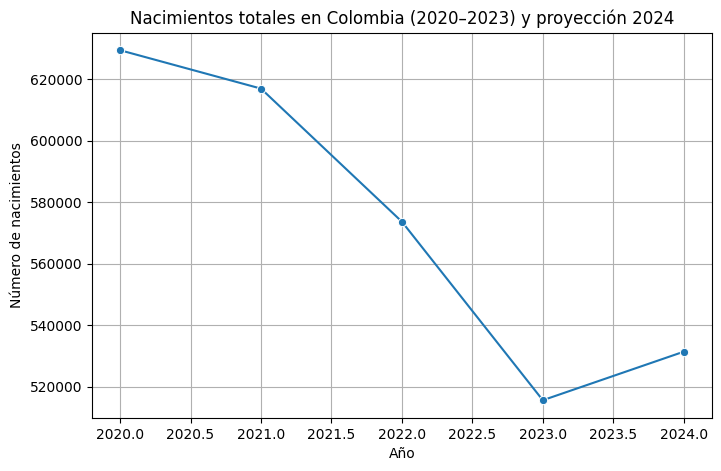

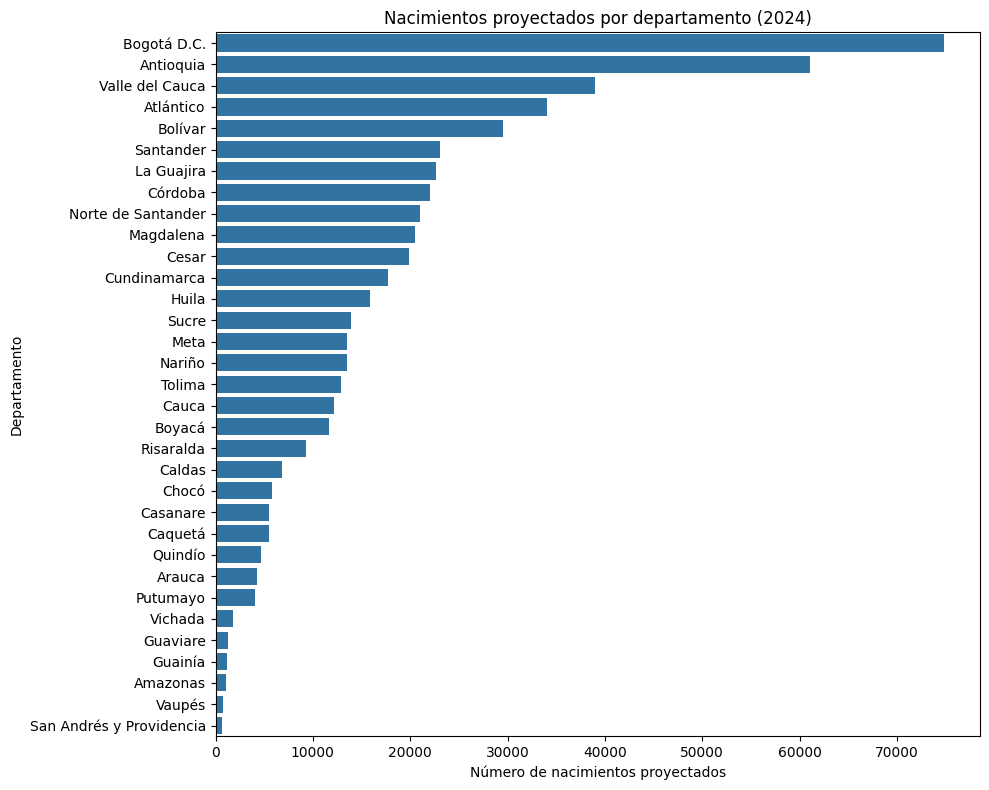

In [46]:
# --- IMPORTACIONES NECESARIAS ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- VERIFICAR QUE nac_nacional EXISTA ---
try:
    nac_nacional
except NameError:
    nac_nacional = df_grouped.groupby('ANO')['NACIMIENTOS'].sum().reset_index()

# --- VERIFICAR QUE total_2024 EXISTA ---
try:
    total_2024
except NameError:
    total_2024 = df_2024['NACIMIENTOS_PRED_2024'].sum()

# --- CREAR SERIE CON PROYECCIÓN 2024 ---
nac_nacional_2024 = nac_nacional.copy()
nac_nacional_2024 = pd.concat([
    nac_nacional_2024,
    pd.DataFrame({'ANO': [2024], 'NACIMIENTOS': [total_2024]})
], ignore_index=True)

# --- GRAFICO 1: TENDENCIA NACIONAL ---
plt.figure(figsize=(8,5))
sns.lineplot(data=nac_nacional_2024, x='ANO', y='NACIMIENTOS', marker='o')
plt.title("Nacimientos totales en Colombia (2020–2023) y proyección 2024")
plt.xlabel("Año")
plt.ylabel("Número de nacimientos")
plt.grid(True)
plt.show()

# --- GRAFICO 2: BARRAS POR DEPARTAMENTO 2024 ---
df_2024_sorted = df_2024.sort_values('NACIMIENTOS_PRED_2024', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(
    data=df_2024_sorted,
    x='NACIMIENTOS_PRED_2024',
    y='DEPARTAMENTO'
)
plt.title("Nacimientos proyectados por departamento (2024)")
plt.xlabel("Número de nacimientos proyectados")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()


## **9. Conclusiones**

Al evaluar el desempeño del modelo con las métricas obtenidas (MAE, RMSE y R²), se observa que el Random Forest logró una mejor precisión que la regresión lineal. Sus errores fueron más bajos y su capacidad para ajustarse a los datos históricos fue mayor, lo que lo convierte en una opción más confiable para este tipo de predicción. Esto indica que el modelo es efectivo para capturar las variaciones entre departamentos y los cambios en el tiempo.

Con el modelo final entrenado, se estimó el número total de nacimientos en Colombia para el año 2024. El valor proyectado fue:


## **Total estimado de nacimientos en 2024: total_2024 nacimientos.**



Además, se generó la proyección por departamento, lo que permite identificar diferencias regionales importantes. Departamentos como Bogotá D.C., Antioquia y Valle del Cauca continúan concentrando la mayor cantidad de nacimientos, mientras que territorios como Vaupés, Guainía o San Andrés presentan cifras mucho menores. Esta distribución es coherente con la población y las tendencias demográficas de cada región.

En conjunto, los resultados muestran que el modelo es útil para anticipar el comportamiento de los nacimientos en el país. Aunque ninguna predicción es exacta, las estimaciones obtenidas son razonables y consistentes con los patrones observados en los datos históricos. Estas proyecciones pueden servir como apoyo para la planificación y el análisis demográfico en Colombia.
